# Reconhecimento Facial de Alunos em Tempo Real

Notebook usando **70.000 amostras** do dataset `chronopt-research/cropped-vggface2-224`.

## Objetivo

Validar um pipeline de reconhecimento facial compatível com o projeto de presença facial:

```text
imagem/frame
↓
buffalo_s
↓
embedding facial
↓
busca vetorial
↓
rejeição de desconhecidos
↓
classificador auxiliar
↓
multi-pessoas no mesmo frame
↓
tracking temporal
↓
comparação com ResNet50
```

## Algoritmos avaliados

1. `buffalo_s + busca vetorial`
2. `buffalo_s + classificador auxiliar`
   - LogisticRegression
   - RandomForest
   - HistGradientBoosting
3. `ResNet50` com transfer learning e fine-tuning
4. Avaliação open-set
5. Avaliação multi-pessoas
6. Simulação de tracking por IoU


# 1. Instalação no Colab

Antes de rodar, ative GPU em:

```text
Ambiente de execução > Alterar tipo de ambiente de execução > GPU
```


In [1]:
!pip install -q datasets insightface opencv-python-headless scikit-learn matplotlib pandas tqdm joblib faiss-cpu seaborn
!pip install -q onnxruntime-gpu || pip install -q onnxruntime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 5.2 MB/s eta 0:00:00


In [2]:
import os
import gc
import json
import math
import time
import random
import shutil
import warnings
from pathlib import Path
from datetime import datetime

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageEnhance
from tqdm.auto import tqdm

from datasets import load_dataset

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from insightface.app import FaceAnalysis

warnings.filterwarnings("ignore")


# 2. Configuração global

Esta configuração usa 70 mil imagens e todas as identidades válidas encontradas dentro dessa amostra.

Para evitar o erro de multiprocessing do Colab, `NUM_WORKERS = 0`.


In [3]:
SEED = 42

DATASET_NAME = "chronopt-research/cropped-vggface2-224"
DATASET_SPLIT = "train"

# usa 70 mil amostras do dataset
TOTAL_AMOSTRAS_DATASET = 70_000

# usa todas as identidades válidas encontradas dentro dessas 70 mil imagens
USAR_TODAS_IDENTIDADES_VALIDAS = True
MIN_IMAGENS_POR_IDENTIDADE = 10

# None = usa todas as imagens disponíveis da identidade dentro das 70 mil
MAX_IMAGENS_POR_IDENTIDADE = None

# separa identidades totalmente desconhecidas para teste open-set
FRACAO_IDENTIDADES_DESCONHECIDAS = 0.15

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# modelo principal do projeto
INSIGHTFACE_MODEL = "buffalo_s"
DET_SIZE = 320

# ResNet50
BATCH_SIZE = 32
EPOCHS_RESNET_HEAD = 8
EPOCHS_RESNET_FINETUNE = 10
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINETUNE = 1e-5
PATIENCE = 4

# Colab: evitar DataLoader multiprocessing
NUM_WORKERS = 0

# multi-pessoas
MULTI_TOTAL_FRAMES = 120
PESSOAS_POR_FRAME_LISTA = [2, 3, 4, 6]

# tracking
TRACKING_TOTAL_SEQUENCIAS = 30
TRACKING_FRAMES_POR_SEQUENCIA = 12
TRACKING_PESSOAS_POR_SEQUENCIA = 4

BASE_DIR = Path("/content")
PASTA_ARTEFATOS = BASE_DIR / "artefatos_reconhecimento"
PASTA_ARTEFATOS.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = DEVICE == "cuda"

print("Dispositivo:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

print("Dataset:", DATASET_NAME)
print("Total de amostras carregadas:", TOTAL_AMOSTRAS_DATASET)
print("Usar todas identidades válidas:", USAR_TODAS_IDENTIDADES_VALIDAS)
print("Mínimo de imagens por identidade:", MIN_IMAGENS_POR_IDENTIDADE)
print("Máximo de imagens por identidade:", MAX_IMAGENS_POR_IDENTIDADE)
print("Modelo principal:", INSIGHTFACE_MODEL)
print("Detector size:", DET_SIZE)
print("Artefatos:", PASTA_ARTEFATOS)


Dispositivo: cuda
GPU: Tesla T4
Dataset: chronopt-research/cropped-vggface2-224
Total de amostras carregadas: 70000
Usar todas identidades válidas: True
Mínimo de imagens por identidade: 10
Máximo de imagens por identidade: None
Modelo principal: buffalo_s
Detector size: 320
Artefatos: /content/artefatos_reconhecimento


In [4]:
!nvidia-smi


Sun May 31 20:17:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 3. Carregamento das 70 mil amostras

O notebook carrega exatamente 70.000 amostras do dataset.


In [5]:
dataset_bruto = load_dataset(
    DATASET_NAME,
    split=f"{DATASET_SPLIT}[:{TOTAL_AMOSTRAS_DATASET}]",
)

print(dataset_bruto)
print(dataset_bruto.features)
print(dataset_bruto.column_names)


README.md:   0%|          | 0.00/237k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

data/train-00000-of-00040.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

data/train-00001-of-00040.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

...

data/validation-00001-of-00003.parquet:   0%|          | 0.00/347M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/346M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3138862 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/169178 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label'],
    num_rows: 70000
})
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['n000001', 'n000002', 'n000003', 'n000004', 'n000005', 'n000006', 'n000007', 'n000008', 'n000009', 'n000010', 'n000011', 'n000012', 'n000013', 'n000014', 'n000015', 'n000016', 'n000017', 'n000018', 'n000019', 'n000020', 'n000021', 'n000022', 'n000023', 'n000024', 'n000025', 'n000026', 'n000027', 'n000028', 'n000029', 'n000030', 'n000031', 'n000032', 'n000033', 'n000034', 'n000035', 'n000036', 'n000037', 'n000038', 'n000039', 'n000040', 'n000041', 'n000042', 'n000043', 'n000044', 'n000045', 'n000046', 'n000047', 'n000048', 'n000049', 'n000050', 'n000051', 'n000052', 'n000053', 'n000054', 'n000055', 'n000056', 'n000057', 'n000058', 'n000059', 'n000060', 'n000061', 'n000062', 'n000063', 'n000064', 'n000065', 'n000066', 'n000067', 'n000068', 'n000069', 'n000070', 'n000071', 'n000072', 'n000073', 'n000074', 'n000075', 'n000076', 'n000077', 'n000078', 'n00007

In [6]:
COLUNA_IMAGEM = "image"

possiveis_colunas_label = ["label", "identity", "person_id", "class", "name"]
COLUNA_LABEL = None

for coluna in possiveis_colunas_label:
    if coluna in dataset_bruto.column_names:
        COLUNA_LABEL = coluna
        break

if COLUNA_LABEL is None:
    raise ValueError(f"nenhuma coluna de label encontrada: {dataset_bruto.column_names}")

print("coluna de imagem:", COLUNA_IMAGEM)
print("coluna de label:", COLUNA_LABEL)


coluna de imagem: image
coluna de label: label


# 4. Verificação do tamanho das imagens


verificando tamanhos:   0%|          | 0/3000 [00:00<?, ?it/s]

,largura,altura
count,3000.0,3000.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0


,largura,altura,quantidade
0,224,224,3000


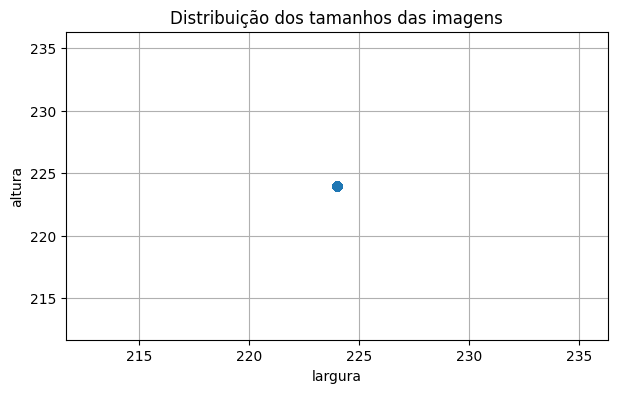

In [7]:
def carregar_imagem_por_indice(indice):
    item = dataset_bruto[int(indice)]
    imagem = item[COLUNA_IMAGEM]
    if not isinstance(imagem, Image.Image):
        imagem = Image.open(imagem)
    return imagem.convert("RGB")

total_verificacao = min(3000, len(dataset_bruto))

tamanhos = []
for indice in tqdm(range(total_verificacao), desc="verificando tamanhos"):
    imagem = carregar_imagem_por_indice(indice)
    tamanhos.append(imagem.size)

df_tamanhos = pd.DataFrame(tamanhos, columns=["largura", "altura"])

display(df_tamanhos.describe())
display(df_tamanhos.value_counts().reset_index(name="quantidade").head(10))

plt.figure(figsize=(7, 4))
plt.scatter(df_tamanhos["largura"], df_tamanhos["altura"], alpha=0.3)
plt.xlabel("largura")
plt.ylabel("altura")
plt.title("Distribuição dos tamanhos das imagens")
plt.grid(True)
plt.show()


# 5. Seleção das identidades válidas

Dentro das 70 mil amostras, serão usadas todas as identidades com pelo menos `MIN_IMAGENS_POR_IDENTIDADE` imagens.

Depois, uma parte das identidades será separada como **desconhecida** para avaliar open-set.


Total carregado inicialmente: 70000
Total de imagens usadas após filtro: 70000
Total de imagens descartadas: 0
Total de identidades usadas: 194
Média de imagens por identidade: 360.82474226804123
Mínimo de imagens por identidade: 123
Máximo de imagens por identidade: 647


,indice,label,label_str
0,67288,198,198
1,67641,198,198
2,67401,198,198
3,67604,198,198
4,67396,198,198


,count
count,194.000000
mean,360.824742
std,97.948333
min,123.000000
25%,289.250000
50%,371.500000
75%,429.000000
max,647.000000


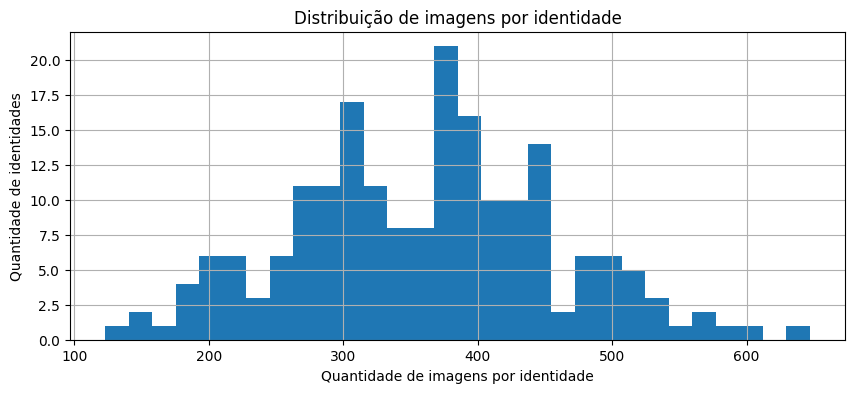

In [8]:
labels = [dataset_bruto[i][COLUNA_LABEL] for i in range(len(dataset_bruto))]

df_indices = pd.DataFrame({
    "indice": list(range(len(dataset_bruto))),
    "label": labels,
})

contagem = df_indices["label"].value_counts()

labels_validos = contagem[
    contagem >= MIN_IMAGENS_POR_IDENTIDADE
].index.tolist()

labels_selecionados = labels_validos

linhas = []

for label in labels_selecionados:
    candidatos = df_indices[df_indices["label"] == label]["indice"].tolist()
    random.shuffle(candidatos)

    if MAX_IMAGENS_POR_IDENTIDADE is None:
        escolhidos = candidatos
    else:
        escolhidos = candidatos[:MAX_IMAGENS_POR_IDENTIDADE]

    for indice in escolhidos:
        linhas.append({
            "indice": int(indice),
            "label": label,
        })

df_amostras = pd.DataFrame(linhas)
df_amostras["label_str"] = df_amostras["label"].astype(str)

imagens_por_identidade = df_amostras["label_str"].value_counts()

print("Total carregado inicialmente:", len(dataset_bruto))
print("Total de imagens usadas após filtro:", len(df_amostras))
print("Total de imagens descartadas:", len(dataset_bruto) - len(df_amostras))
print("Total de identidades usadas:", df_amostras["label_str"].nunique())
print("Média de imagens por identidade:", imagens_por_identidade.mean())
print("Mínimo de imagens por identidade:", imagens_por_identidade.min())
print("Máximo de imagens por identidade:", imagens_por_identidade.max())

display(df_amostras.head())
display(imagens_por_identidade.describe())

plt.figure(figsize=(10, 4))
plt.hist(imagens_por_identidade.values, bins=30)
plt.title("Distribuição de imagens por identidade")
plt.xlabel("Quantidade de imagens por identidade")
plt.ylabel("Quantidade de identidades")
plt.grid(True)
plt.show()


# 6. Divisão em treino, validação, teste e desconhecidos

- Identidades conhecidas: simulam alunos cadastrados.
- Identidades desconhecidas: simulam pessoas não cadastradas.

As identidades desconhecidas **não entram no treino**.


In [9]:
def dividir_por_identidade_conhecida(df, train_ratio=0.70, val_ratio=0.15):
    partes = []

    for label, grupo in df.groupby("label_str"):
        indices = grupo["indice"].tolist()
        random.shuffle(indices)

        n = len(indices)
        n_train = max(1, int(n * train_ratio))
        n_val = max(1, int(n * val_ratio))
        n_test = n - n_train - n_val

        if n_test < 1:
            n_test = 1
            if n_train > n_val:
                n_train -= 1
            else:
                n_val -= 1

        for indice in indices[:n_train]:
            partes.append({"indice": indice, "label_str": label, "split": "train", "tipo": "known"})

        for indice in indices[n_train:n_train+n_val]:
            partes.append({"indice": indice, "label_str": label, "split": "val", "tipo": "known"})

        for indice in indices[n_train+n_val:]:
            partes.append({"indice": indice, "label_str": label, "split": "test", "tipo": "known"})

    return pd.DataFrame(partes)

def dividir_desconhecidos(df):
    partes = []

    for label, grupo in df.groupby("label_str"):
        indices = grupo["indice"].tolist()
        random.shuffle(indices)

        corte = max(1, len(indices) // 2)

        for indice in indices[:corte]:
            partes.append({"indice": indice, "label_str": label, "split": "val_unknown", "tipo": "unknown"})

        for indice in indices[corte:]:
            partes.append({"indice": indice, "label_str": label, "split": "test_unknown", "tipo": "unknown"})

    return pd.DataFrame(partes)

todos_labels = df_amostras["label_str"].unique().tolist()
random.shuffle(todos_labels)

qtd_unknown = max(1, int(len(todos_labels) * FRACAO_IDENTIDADES_DESCONHECIDAS))

labels_unknown = set(todos_labels[:qtd_unknown])
labels_known = set(todos_labels[qtd_unknown:])

df_known_base = df_amostras[df_amostras["label_str"].isin(labels_known)].copy()
df_unknown_base = df_amostras[df_amostras["label_str"].isin(labels_unknown)].copy()

df_known_split = dividir_por_identidade_conhecida(df_known_base, TRAIN_RATIO, VAL_RATIO)
df_unknown_split = dividir_desconhecidos(df_unknown_base)

df_split = pd.concat([df_known_split, df_unknown_split], ignore_index=True)

display(df_split.groupby(["tipo", "split"]).size())
display(df_split.groupby("split")["label_str"].nunique())

print("Identidades conhecidas:", len(labels_known))
print("Identidades desconhecidas:", len(labels_unknown))
print("Total imagens no experimento:", len(df_split))


tipo     split       
known    test             9027
         train           41294
         val              8782
unknown  test_unknown     5455
         val_unknown      5442
dtype: int64

,label_str
split,
test,165
test_unknown,29
train,165
val,165
val_unknown,29


Identidades conhecidas: 165
Identidades desconhecidas: 29
Total imagens no experimento: 70000


In [10]:
label_encoder = LabelEncoder()
label_encoder.fit(sorted(list(labels_known)))

df_split["label_id"] = -1
mascara_known = df_split["label_str"].isin(labels_known)
df_split.loc[mascara_known, "label_id"] = label_encoder.transform(df_split.loc[mascara_known, "label_str"])

NUM_CLASSES = len(label_encoder.classes_)
print("Classes conhecidas para ResNet50:", NUM_CLASSES)


Classes conhecidas para ResNet50: 165


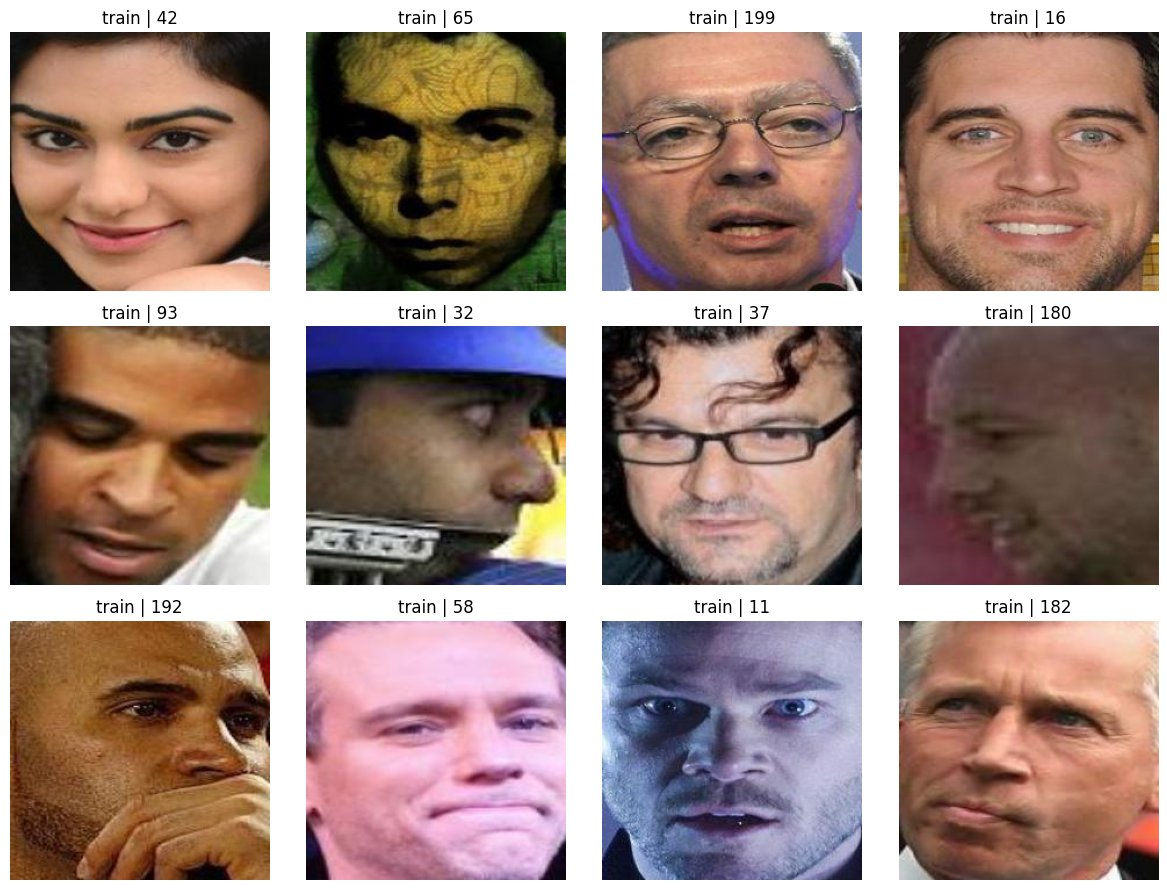

In [11]:
def mostrar_amostras(df, n=12):
    amostra = df.sample(n=min(n, len(df)), random_state=SEED)
    colunas = 4
    linhas = math.ceil(len(amostra) / colunas)

    plt.figure(figsize=(12, 3 * linhas))

    for pos, (_, linha) in enumerate(amostra.iterrows(), start=1):
        imagem = carregar_imagem_por_indice(linha["indice"])
        plt.subplot(linhas, colunas, pos)
        plt.imshow(imagem)
        plt.title(f"{linha['split']} | {linha['label_str']}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

mostrar_amostras(df_split[df_split["split"] == "train"], n=12)


# 7. Pipeline principal: buffalo_s + embeddings


In [12]:
ctx_id = 0 if DEVICE == "cuda" else -1

face_app = FaceAnalysis(name=INSIGHTFACE_MODEL)
face_app.prepare(ctx_id=ctx_id, det_size=(DET_SIZE, DET_SIZE))

print("modelo:", INSIGHTFACE_MODEL)
print("ctx_id:", ctx_id)
print("det_size:", DET_SIZE)


download_path: /root/.insightface/models/buffalo_s


100%|██████████| 124617/124617 [00:01<00:00, 93762.47KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_s/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

In [13]:
def extrair_embedding_buffalo_s(imagem_pil):
    imagem_np = np.array(imagem_pil.convert("RGB"))
    faces = face_app.get(imagem_np)

    if not faces:
        return None

    face = max(
        faces,
        key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]),
    )

    embedding = face.embedding.astype("float32")
    embedding = embedding / (np.linalg.norm(embedding) + 1e-12)

    return embedding

def extrair_embeddings_dataframe(df, descricao):
    registros = []
    falhas = 0

    for _, linha in tqdm(df.iterrows(), total=len(df), desc=descricao):
        imagem = carregar_imagem_por_indice(linha["indice"])
        embedding = extrair_embedding_buffalo_s(imagem)

        if embedding is None:
            falhas += 1
            continue

        registros.append({
            "indice": int(linha["indice"]),
            "label_str": linha["label_str"],
            "label_id": int(linha["label_id"]),
            "split": linha["split"],
            "tipo": linha["tipo"],
            "embedding": embedding,
        })

    df_embeddings = pd.DataFrame(registros)
    print(f"{descricao} | sucesso={len(df_embeddings)} | falhas={falhas}")

    return df_embeddings

df_embeddings_train = extrair_embeddings_dataframe(
    df_split[df_split["split"] == "train"],
    "embeddings train",
)

df_embeddings_val = extrair_embeddings_dataframe(
    df_split[df_split["split"] == "val"],
    "embeddings val known",
)

df_embeddings_test = extrair_embeddings_dataframe(
    df_split[df_split["split"] == "test"],
    "embeddings test known",
)

df_embeddings_val_unknown = extrair_embeddings_dataframe(
    df_split[df_split["split"] == "val_unknown"],
    "embeddings val unknown",
)

df_embeddings_test_unknown = extrair_embeddings_dataframe(
    df_split[df_split["split"] == "test_unknown"],
    "embeddings test unknown",
)


embeddings train:   0%|          | 0/41294 [00:00<?, ?it/s]

embeddings train | sucesso=41073 | falhas=221


embeddings val known:   0%|          | 0/8782 [00:00<?, ?it/s]

embeddings val known | sucesso=8737 | falhas=45


embeddings test known:   0%|          | 0/9027 [00:00<?, ?it/s]

embeddings test known | sucesso=8986 | falhas=41


embeddings val unknown:   0%|          | 0/5442 [00:00<?, ?it/s]

embeddings val unknown | sucesso=5424 | falhas=18


embeddings test unknown:   0%|          | 0/5455 [00:00<?, ?it/s]

embeddings test unknown | sucesso=5435 | falhas=20


In [14]:
def matriz_embeddings(df_embeddings):
    if len(df_embeddings) == 0:
        return np.empty((0, 512), dtype="float32")
    return np.vstack(df_embeddings["embedding"].values).astype("float32")

X_train_emb = matriz_embeddings(df_embeddings_train)
y_train_emb = df_embeddings_train["label_str"].values

X_val_emb = matriz_embeddings(df_embeddings_val)
y_val_emb = df_embeddings_val["label_str"].values

X_test_emb = matriz_embeddings(df_embeddings_test)
y_test_emb = df_embeddings_test["label_str"].values

X_val_unknown_emb = matriz_embeddings(df_embeddings_val_unknown)
X_test_unknown_emb = matriz_embeddings(df_embeddings_test_unknown)

print("train:", X_train_emb.shape)
print("val known:", X_val_emb.shape)
print("test known:", X_test_emb.shape)
print("val unknown:", X_val_unknown_emb.shape)
print("test unknown:", X_test_unknown_emb.shape)


train: (41073, 512)
val known: (8737, 512)
test known: (8986, 512)
val unknown: (5424, 512)
test unknown: (5435, 512)


# 8. Busca vetorial com NumPy/FAISS


In [15]:
def criar_centroides(df_embeddings):
    centroides = {}

    for label, grupo in df_embeddings.groupby("label_str"):
        matriz = matriz_embeddings(grupo)
        centroide = matriz.mean(axis=0)
        centroide = centroide / (np.linalg.norm(centroide) + 1e-12)
        centroides[label] = centroide.astype("float32")

    labels = np.array(list(centroides.keys()))
    matriz = np.vstack([centroides[label] for label in labels]).astype("float32")

    return matriz, labels

centroides_train, labels_centroides = criar_centroides(df_embeddings_train)

try:
    import faiss
    USAR_FAISS = True
    indice_faiss = faiss.IndexFlatIP(centroides_train.shape[1])
    indice_faiss.add(centroides_train)
    print("FAISS ativo:", indice_faiss.ntotal)
except Exception as erro:
    USAR_FAISS = False
    indice_faiss = None
    print("FAISS indisponível. usando NumPy.", erro)

def buscar_topk(embeddings_consulta, top_k=3):
    embeddings_consulta = embeddings_consulta.astype("float32")

    if USAR_FAISS:
        scores, indices = indice_faiss.search(embeddings_consulta, top_k)
    else:
        matriz_scores = embeddings_consulta @ centroides_train.T
        indices = np.argsort(matriz_scores, axis=1)[:, ::-1][:, :top_k]
        scores = np.take_along_axis(matriz_scores, indices, axis=1)

    labels_pred = labels_centroides[indices]
    return labels_pred, scores


FAISS ativo: 165


In [16]:
def avaliar_identificacao_fechada(embeddings, labels_reais, nome_split):
    labels_topk, scores_topk = buscar_topk(embeddings, top_k=3)

    top1 = labels_topk[:, 0]
    top3_correto = [
        labels_reais[i] in labels_topk[i]
        for i in range(len(labels_reais))
    ]

    return {
        "split": nome_split,
        "top1_accuracy": accuracy_score(labels_reais, top1),
        "top3_accuracy": float(np.mean(top3_correto)),
        "macro_f1_top1": f1_score(labels_reais, top1, average="macro"),
        "macro_precision_top1": precision_score(labels_reais, top1, average="macro", zero_division=0),
        "macro_recall_top1": recall_score(labels_reais, top1, average="macro", zero_division=0),
        "mean_top1_score": float(np.mean(scores_topk[:, 0])),
    }, top1, scores_topk[:, 0]

metricas_id_val, pred_val_top1, score_val_top1 = avaliar_identificacao_fechada(
    X_val_emb,
    y_val_emb,
    "val_known",
)

metricas_id_test, pred_test_top1, score_test_top1 = avaliar_identificacao_fechada(
    X_test_emb,
    y_test_emb,
    "test_known",
)

df_metricas_identificacao = pd.DataFrame([metricas_id_val, metricas_id_test])
df_metricas_identificacao


,split,top1_accuracy,top3_accuracy,macro_f1_top1,macro_precision_top1,macro_recall_top1,mean_top1_score
0,val_known,0.983175,0.989356,0.981484,0.982216,0.981383,0.618562
1,test_known,0.985867,0.991320,0.983990,0.984815,0.983709,0.620902


# 9. Open-set: rejeição de desconhecidos


In [17]:
def scores_top1(embeddings):
    labels_topk, scores_topk = buscar_topk(embeddings, top_k=1)
    return labels_topk[:, 0], scores_topk[:, 0]

pred_val_known, scores_val_known = scores_top1(X_val_emb)
pred_val_unknown, scores_val_unknown = scores_top1(X_val_unknown_emb)

y_open_val = np.concatenate([
    np.ones(len(scores_val_known)),
    np.zeros(len(scores_val_unknown)),
])

scores_open_val = np.concatenate([
    scores_val_known,
    scores_val_unknown,
])

fpr, tpr, thresholds = roc_curve(y_open_val, scores_open_val)
fnr = 1 - tpr
idx_eer = np.nanargmin(np.abs(fnr - fpr))

threshold_open_set = float(thresholds[idx_eer])
eer_open_set = float((fpr[idx_eer] + fnr[idx_eer]) / 2)

print("threshold open-set:", threshold_open_set)
print("EER open-set validação:", eer_open_set)
print("AUC open-set validação:", roc_auc_score(y_open_val, scores_open_val))

pred_test_known, scores_test_known = scores_top1(X_test_emb)
pred_test_unknown, scores_test_unknown = scores_top1(X_test_unknown_emb)

known_accepted = scores_test_known >= threshold_open_set
unknown_rejected = scores_test_unknown < threshold_open_set

known_correct_and_accepted = [
    known_accepted[i] and pred_test_known[i] == y_test_emb[i]
    for i in range(len(y_test_emb))
]

metricas_open_set = {
    "threshold": threshold_open_set,
    "known_acceptance_rate": float(np.mean(known_accepted)),
    "known_correct_acceptance_rate": float(np.mean(known_correct_and_accepted)),
    "unknown_rejection_rate": float(np.mean(unknown_rejected)),
    "false_acceptance_rate_far": float(1 - np.mean(unknown_rejected)),
    "false_rejection_rate_frr": float(1 - np.mean(known_accepted)),
    "open_set_balanced_accuracy": float((np.mean(known_accepted) + np.mean(unknown_rejected)) / 2),
}

pd.DataFrame([metricas_open_set])


threshold open-set: 0.33789435029029846
EER open-set validação: 0.034784887315094014
AUC open-set validação: 0.9860428224082101


,threshold,known_acceptance_rate,known_correct_acceptance_rate,unknown_rejection_rate,false_acceptance_rate_far,false_rejection_rate_frr,open_set_balanced_accuracy
0,0.337894,0.966281,0.965502,0.960442,0.039558,0.033719,0.963361


# 10. Classificador auxiliar match/non-match


In [18]:
def features_par_embeddings(a, b):
    diff = np.abs(a - b)

    return np.array([
        float(np.dot(a, b)),
        float(np.linalg.norm(a - b)),
        float(diff.mean()),
        float(diff.max()),
        float(diff.min()),
        float(diff.std()),
    ], dtype="float32")

FEATURE_NAMES = [
    "cosine_similarity",
    "l2_distance",
    "abs_diff_mean",
    "abs_diff_max",
    "abs_diff_min",
    "abs_diff_std",
]

def gerar_pares(df_embeddings, pares_positivos_por_classe=60, proporcao_negativos=1):
    rng = np.random.default_rng(SEED)

    embeddings_por_label = {
        label: grupo["embedding"].tolist()
        for label, grupo in df_embeddings.groupby("label_str")
    }

    labels = list(embeddings_por_label.keys())

    X = []
    y = []

    for label in tqdm(labels, desc="gerando pares"):
        embs = embeddings_por_label[label]

        if len(embs) < 2:
            continue

        repeticoes = min(pares_positivos_por_classe, len(embs) * 2)

        for _ in range(repeticoes):
            i, j = rng.choice(len(embs), size=2, replace=False)
            X.append(features_par_embeddings(embs[i], embs[j]))
            y.append(1)

            for _ in range(proporcao_negativos):
                label_neg = rng.choice([l for l in labels if l != label])
                emb_neg = embeddings_por_label[label_neg][rng.integers(0, len(embeddings_por_label[label_neg]))]
                emb_pos = embs[i]

                X.append(features_par_embeddings(emb_pos, emb_neg))
                y.append(0)

    return np.vstack(X).astype("float32"), np.array(y).astype("int32")

X_pair_train, y_pair_train = gerar_pares(df_embeddings_train, pares_positivos_por_classe=60)
X_pair_val, y_pair_val = gerar_pares(df_embeddings_val, pares_positivos_por_classe=30)
X_pair_test, y_pair_test = gerar_pares(df_embeddings_test, pares_positivos_por_classe=30)

print(X_pair_train.shape, y_pair_train.mean())
print(X_pair_val.shape, y_pair_val.mean())
print(X_pair_test.shape, y_pair_test.mean())


gerando pares:   0%|          | 0/165 [00:00<?, ?it/s]

gerando pares:   0%|          | 0/165 [00:00<?, ?it/s]

gerando pares:   0%|          | 0/165 [00:00<?, ?it/s]

(19800, 6) 0.5
(9900, 6) 0.5
(9900, 6) 0.5


In [19]:
modelos_verificacao = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=250,
        random_state=SEED,
    ),
}

resultados_verificacao = []
modelos_treinados = {}

for nome, modelo in modelos_verificacao.items():
    modelo.fit(X_pair_train, y_pair_train)

    proba_val = modelo.predict_proba(X_pair_val)[:, 1]
    proba_test = modelo.predict_proba(X_pair_test)[:, 1]

    fpr_v, tpr_v, thresholds_v = roc_curve(y_pair_val, proba_val)
    fnr_v = 1 - tpr_v
    idx_eer_v = np.nanargmin(np.abs(fnr_v - fpr_v))
    threshold_eer = float(thresholds_v[idx_eer_v])

    pred_test_eer = (proba_test >= threshold_eer).astype(int)

    resultados_verificacao.append({
        "modelo": nome,
        "auc_val": roc_auc_score(y_pair_val, proba_val),
        "auc_test": roc_auc_score(y_pair_test, proba_test),
        "threshold_eer_val": threshold_eer,
        "eer_val": float((fpr_v[idx_eer_v] + fnr_v[idx_eer_v]) / 2),
        "f1_test_eer": f1_score(y_pair_test, pred_test_eer),
        "precision_test_eer": precision_score(y_pair_test, pred_test_eer, zero_division=0),
        "recall_test_eer": recall_score(y_pair_test, pred_test_eer, zero_division=0),
    })

    modelos_treinados[nome] = {
        "modelo": modelo,
        "threshold": threshold_eer,
    }

df_resultados_verificacao = pd.DataFrame(resultados_verificacao).sort_values(
    "auc_test",
    ascending=False,
)

display(df_resultados_verificacao)

melhor_nome_verificador = df_resultados_verificacao.iloc[0]["modelo"]
melhor_verificador = modelos_treinados[melhor_nome_verificador]["modelo"]
melhor_threshold = modelos_treinados[melhor_nome_verificador]["threshold"]

print("melhor verificador:", melhor_nome_verificador)
print("threshold:", melhor_threshold)


,modelo,auc_val,auc_test,threshold_eer_val,eer_val,f1_test_eer,precision_test_eer,recall_test_eer
0,LogisticRegression,0.986027,0.988547,0.384974,0.049596,0.955384,0.959080,0.951717
2,HistGradientBoosting,0.985671,0.987938,0.322455,0.051111,0.955384,0.959080,0.951717
1,RandomForest,0.983692,0.985502,0.344000,0.054545,0.952111,0.954333,0.949899


melhor verificador: LogisticRegression
threshold: 0.38497350773991224


# 11. ResNet50 com transfer learning e fine-tuning


In [20]:
class DatasetFacesResNet(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        linha = self.df.iloc[idx]
        imagem = carregar_imagem_por_indice(linha["indice"])
        imagem = self.transform(imagem)
        label = int(linha["label_id"])
        return imagem, label

weights_resnet = ResNet50_Weights.IMAGENET1K_V2
mean = weights_resnet.transforms().mean
std = weights_resnet.transforms().std

transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

df_train = df_split[df_split["split"] == "train"].copy()
df_val = df_split[df_split["split"] == "val"].copy()
df_test = df_split[df_split["split"] == "test"].copy()

loader_train = DataLoader(
    DatasetFacesResNet(df_train, transform_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

loader_val = DataLoader(
    DatasetFacesResNet(df_val, transform_eval),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

loader_test = DataLoader(
    DatasetFacesResNet(df_test, transform_eval),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("train batches:", len(loader_train))
print("val batches:", len(loader_val))
print("test batches:", len(loader_test))


train batches: 1291
val batches: 275
test batches: 283


In [21]:
def criar_resnet50(num_classes):
    modelo = resnet50(weights=weights_resnet)

    for parametro in modelo.parameters():
        parametro.requires_grad = False

    in_features = modelo.fc.in_features
    modelo.fc = nn.Sequential(
        nn.Dropout(p=0.35),
        nn.Linear(in_features, num_classes),
    )

    return modelo.to(DEVICE)

modelo_resnet = criar_resnet50(NUM_CLASSES)
criterio = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

print(modelo_resnet.fc)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 110MB/s] 


Sequential(
  (0): Dropout(p=0.35, inplace=False)
  (1): Linear(in_features=2048, out_features=165, bias=True)
)


In [22]:
def avaliar_resnet(modelo, loader):
    modelo.eval()

    y_true = []
    y_pred = []
    perdas = []

    with torch.no_grad():
        for imagens, labels in loader:
            imagens = imagens.to(DEVICE)
            labels = labels.to(DEVICE)

            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                logits = modelo(imagens)
                loss = criterio(logits, labels)

            perdas.append(loss.item())

            preds = logits.argmax(dim=1)

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    return {
        "loss": float(np.mean(perdas)),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "y_true": y_true,
        "y_pred": y_pred,
    }

def salvar_checkpoint_resnet(modelo, historico, nome):
    caminho = PASTA_ARTEFATOS / nome
    torch.save({
        "model_state_dict": modelo.state_dict(),
        "historico": historico,
        "classes": label_encoder.classes_.tolist(),
        "num_classes": NUM_CLASSES,
        "created_at": datetime.utcnow().isoformat(),
    }, caminho)
    print("checkpoint salvo:", caminho)

def treinar_resnet(modelo, loader_train, loader_val, epochs, lr, descricao):
    otimizador = torch.optim.AdamW(
        [p for p in modelo.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=1e-4,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        otimizador,
        mode="max",
        factor=0.5,
        patience=2,
    )

    historico = []
    melhor_f1 = -1
    melhor_estado = None
    sem_melhora = 0

    for epoch in range(1, epochs + 1):
        modelo.train()

        perdas = []
        y_true_train = []
        y_pred_train = []

        for imagens, labels in tqdm(loader_train, desc=f"{descricao} epoch {epoch}/{epochs}"):
            imagens = imagens.to(DEVICE)
            labels = labels.to(DEVICE)

            otimizador.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                logits = modelo(imagens)
                loss = criterio(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(otimizador)
            scaler.update()

            perdas.append(loss.item())

            preds = logits.argmax(dim=1)
            y_true_train.extend(labels.detach().cpu().numpy().tolist())
            y_pred_train.extend(preds.detach().cpu().numpy().tolist())

        metricas_val = avaliar_resnet(modelo, loader_val)

        linha = {
            "fase": descricao,
            "epoch": epoch,
            "train_loss": float(np.mean(perdas)),
            "train_accuracy": accuracy_score(y_true_train, y_pred_train),
            "train_macro_f1": f1_score(y_true_train, y_pred_train, average="macro"),
            "val_loss": metricas_val["loss"],
            "val_accuracy": metricas_val["accuracy"],
            "val_macro_f1": metricas_val["macro_f1"],
        }

        historico.append(linha)
        scheduler.step(metricas_val["macro_f1"])

        print(linha)
        salvar_checkpoint_resnet(modelo, historico, f"checkpoint_resnet_{descricao}.pth")

        if metricas_val["macro_f1"] > melhor_f1:
            melhor_f1 = metricas_val["macro_f1"]
            melhor_estado = {
                "model_state_dict": modelo.state_dict(),
                "val_macro_f1": melhor_f1,
                "fase": descricao,
                "epoch": epoch,
            }
            sem_melhora = 0
        else:
            sem_melhora += 1

        if sem_melhora >= PATIENCE:
            print("early stopping acionado")
            break

    if melhor_estado is not None:
        modelo.load_state_dict(melhor_estado["model_state_dict"])

    return pd.DataFrame(historico), melhor_estado


In [23]:
# fase 1: treina apenas a cabeça final
historico_head, melhor_head = treinar_resnet(
    modelo_resnet,
    loader_train,
    loader_val,
    epochs=EPOCHS_RESNET_HEAD,
    lr=LEARNING_RATE_HEAD,
    descricao="head",
)


head epoch 1/8:   0%|          | 0/1291 [00:00<?, ?it/s]

{'fase': 'head', 'epoch': 1, 'train_loss': 4.274590855693743, 'train_accuracy': 0.12689494841865645, 'train_macro_f1': 0.10519448872702565, 'val_loss': 3.77437067378651, 'val_accuracy': 0.20143475290366658, 'val_macro_f1': 0.16900686966872552}
checkpoint salvo: /content/artefatos_reconhecimento/checkpoint_resnet_head.pth


head epoch 2/8:   0%|          | 0/1291 [00:00<?, ?it/s]

{'fase': 'head', 'epoch': 2, 'train_loss': 3.577938170141254, 'train_accuracy': 0.22940378747517798, 'train_macro_f1': 0.204843096259135, 'val_loss': 3.4259991177645595, 'val_accuracy': 0.25472557503985427, 'val_macro_f1': 0.2196187682348263}
checkpoint salvo: /content/artefatos_reconhecimento/checkpoint_resnet_head.pth


head epoch 3/8:   0%|          | 0/1291 [00:00<?, ?it/s]

...

{'fase': 'head', 'epoch': 6, 'train_loss': 2.957993578670747, 'train_accuracy': 0.3324211749891025, 'train_macro_f1': 0.3196291175368807, 'val_loss': 2.9238521645285864, 'val_accuracy': 0.34354361193350036, 'val_macro_f1': 0.32174223178019956}
checkpoint salvo: /content/artefatos_reconhecimento/checkpoint_resnet_head.pth


head epoch 7/8:   0%|          | 0/1291 [00:00<?, ?it/s]

{'fase': 'head', 'epoch': 7, 'train_loss': 2.886744170665372, 'train_accuracy': 0.3415508306291471, 'train_macro_f1': 0.3285667712089048, 'val_loss': 2.823132545297796, 'val_accuracy': 0.36176269642450465, 'val_macro_f1': 0.34074775735006246}
checkpoint salvo: /content/artefatos_reconhecimento/checkpoint_resnet_head.pth


head epoch 8/8:   0%|          | 0/1291 [00:00<?, ?it/s]

{'fase': 'head', 'epoch': 8, 'train_loss': 2.84278293555324, 'train_accuracy': 0.3474838959655156, 'train_macro_f1': 0.33490139430875127, 'val_loss': 2.773430910543962, 'val_accuracy': 0.3723525392849009, 'val_macro_f1': 0.3574921938212934}
checkpoint salvo: /content/artefatos_reconhecimento/checkpoint_resnet_head.pth


In [24]:
# fase 2: fine-tuning da layer4 e fc
for nome, parametro in modelo_resnet.named_parameters():
    if nome.startswith("layer4") or nome.startswith("fc"):
        parametro.requires_grad = True
    else:
        parametro.requires_grad = False

historico_finetune, melhor_finetune = treinar_resnet(
    modelo_resnet,
    loader_train,
    loader_val,
    epochs=EPOCHS_RESNET_FINETUNE,
    lr=LEARNING_RATE_FINETUNE,
    descricao="finetune_layer4",
)

historico_resnet = pd.concat([historico_head, historico_finetune], ignore_index=True)
historico_resnet


finetune_layer4 epoch 1/10:   0%|          | 0/1291 [00:00<?, ?it/s]

{'fase': 'finetune_layer4', 'epoch': 1, 'train_loss': 2.4660143681407254, 'train_accuracy': 0.41858381362909863, 'train_macro_f1': 0.40487408178396644, 'val_loss': 2.3203733348846436, 'val_accuracy': 0.45627419722158963, 'val_macro_f1': 0.4403993586300815}
checkpoint salvo: /content/artefatos_reconhecimento/checkpoint_resnet_finetune_layer4.pth


finetune_layer4 epoch 2/10:   0%|          | 0/1291 [00:00<?, ?it/s]

{'fase': 'finetune_layer4', 'epoch': 2, 'train_loss': 2.1669354857076146, 'train_accuracy': 0.4784714486366058, 'train_macro_f1': 0.4671208061904085, 'val_loss': 2.1308492426438765, 'val_accuracy': 0.48929628786153495, 'val_macro_f1': 0.4761736686483637}
checkpoint salvo: /content/artefatos_reconhecimento/checkpoint_resnet_finetune_layer4.pth


finetune_layer4 epoch 3/10:   0%|          | 0/1291 [00:00<?, ?it/s]

...

finetune_layer4 epoch 9/10:   0%|          | 0/1291 [00:00<?, ?it/s]

{'fase': 'finetune_layer4', 'epoch': 9, 'train_loss': 1.4484839986499016, 'train_accuracy': 0.6312781517896062, 'train_macro_f1': 0.6235269793262148, 'val_loss': 1.520249212330038, 'val_accuracy': 0.6191072648599408, 'val_macro_f1': 0.6091126245772042}
checkpoint salvo: /content/artefatos_reconhecimento/checkpoint_resnet_finetune_layer4.pth


finetune_layer4 epoch 10/10:   0%|          | 0/1291 [00:00<?, ?it/s]

{'fase': 'finetune_layer4', 'epoch': 10, 'train_loss': 1.3822984287297422, 'train_accuracy': 0.6426599505981498, 'train_macro_f1': 0.635252960964511, 'val_loss': 1.4762620343945243, 'val_accuracy': 0.6268503757686176, 'val_macro_f1': 0.6182456519374957}
checkpoint salvo: /content/artefatos_reconhecimento/checkpoint_resnet_finetune_layer4.pth


,fase,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1
0,head,1,4.274591,0.126895,0.105194,3.774371,0.201435,0.169007
1,head,2,3.577938,0.229404,0.204843,3.425999,0.254726,0.219619
2,head,3,3.298281,0.276965,0.255733,3.165710,0.303006,0.278957
3,head,4,3.123083,0.304766,0.287301,3.044597,0.323958,0.298086
4,head,5,3.019827,0.320943,0.304753,2.950413,0.350034,0.325168
5,head,6,2.957994,0.332421,0.319629,2.923852,0.343544,0.321742
6,head,7,2.886744,0.341551,0.328567,2.823133,0.361763,0.340748
7,head,8,2.842783,0.347484,0.334901,2.773431,0.372353,0.357492
8,finetune_layer4,1,2.466014,0.418584,0.404874,2.320373,0.456274,0.440399
9,finetune_layer4,2,2.166935,0.478471,0.467121,2.130849,0.489296,0.476174


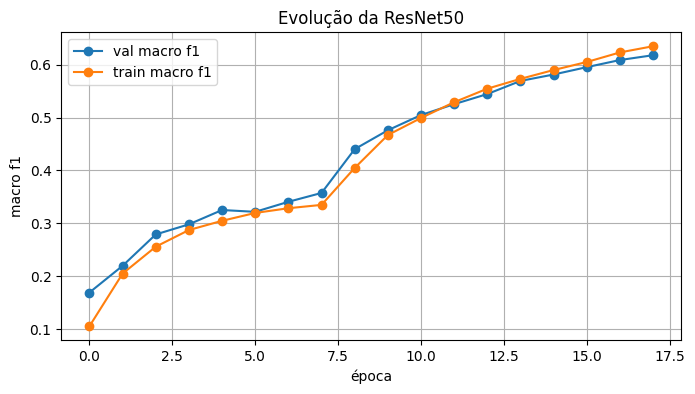

,modelo,test_accuracy,test_macro_f1,test_macro_precision,test_macro_recall
0,ResNet50_finetuned,0.637532,0.624762,0.653555,0.622801


In [25]:
plt.figure(figsize=(8, 4))
plt.plot(historico_resnet["val_macro_f1"], marker="o", label="val macro f1")
plt.plot(historico_resnet["train_macro_f1"], marker="o", label="train macro f1")
plt.xlabel("época")
plt.ylabel("macro f1")
plt.title("Evolução da ResNet50")
plt.legend()
plt.grid(True)
plt.show()

metricas_resnet_test = avaliar_resnet(modelo_resnet, loader_test)

resumo_resnet_test = {
    "modelo": "ResNet50_finetuned",
    "test_accuracy": metricas_resnet_test["accuracy"],
    "test_macro_f1": metricas_resnet_test["macro_f1"],
    "test_macro_precision": metricas_resnet_test["macro_precision"],
    "test_macro_recall": metricas_resnet_test["macro_recall"],
}

pd.DataFrame([resumo_resnet_test])


# 12. Multi-pessoas no mesmo frame


In [26]:
def criar_frame_sintetico(amostras, largura_frame=960, altura_frame=640, tamanho_face=170):
    frame = Image.new("RGB", (largura_frame, altura_frame), color=(235, 235, 235))

    posicoes_base = [
        (40, 40), (280, 40), (520, 40), (760, 40),
        (40, 350), (280, 350), (520, 350), (760, 350),
    ]

    random.shuffle(posicoes_base)
    anotacoes = []

    for indice, amostra in enumerate(amostras):
        imagem = carregar_imagem_por_indice(amostra["indice"])
        imagem = ImageOps.fit(imagem, (tamanho_face, tamanho_face))

        if random.random() < 0.5:
            imagem = ImageEnhance.Brightness(imagem).enhance(random.uniform(0.85, 1.15))

        x, y = posicoes_base[indice]
        x += random.randint(-12, 12)
        y += random.randint(-8, 8)

        frame.paste(imagem, (x, y))

        anotacoes.append({
            "label_str": amostra["label_str"],
            "tipo": amostra.get("tipo", "known"),
            "bbox_gt": [x, y, x + tamanho_face, y + tamanho_face],
        })

    return frame, anotacoes

def calcular_iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union = area_a + area_b - inter_area

    return inter_area / union if union > 0 else 0.0

def reconhecer_frame_completo(frame_pil, top_k=3):
    frame_np = np.array(frame_pil.convert("RGB"))

    inicio = time.perf_counter()
    faces = face_app.get(frame_np)
    latencia_ms = (time.perf_counter() - inicio) * 1000

    resultados = []

    for face in faces:
        embedding = face.embedding.astype("float32")
        embedding = embedding / (np.linalg.norm(embedding) + 1e-12)

        labels_topk, scores_topk = buscar_topk(embedding.reshape(1, -1), top_k=top_k)

        score = float(scores_topk[0, 0])
        label_pred = labels_topk[0, 0]

        if score < threshold_open_set:
            label_final = "desconhecido"
        else:
            label_final = label_pred

        resultados.append({
            "bbox": face.bbox.astype(int).tolist(),
            "pred_label": label_pred,
            "label_final": label_final,
            "score": score,
            "topk": labels_topk[0].tolist(),
        })

    return resultados, latencia_ms


In [27]:
def avaliar_multi_pessoas(total_frames=100, pessoas_por_frame=4):
    registros = []

    df_known_test = df_split[df_split["split"] == "test"].copy()
    df_unknown_test = df_split[df_split["split"] == "test_unknown"].copy()

    labels_known_disponiveis = df_known_test["label_str"].unique().tolist()
    labels_unknown_disponiveis = df_unknown_test["label_str"].unique().tolist()

    for frame_id in tqdm(range(total_frames), desc=f"multi-face {pessoas_por_frame} pessoas"):
        qtd_unknown = 1 if pessoas_por_frame >= 3 and len(labels_unknown_disponiveis) > 0 else 0
        qtd_known = pessoas_por_frame - qtd_unknown

        labels_frame_known = random.sample(labels_known_disponiveis, qtd_known)
        labels_frame_unknown = random.sample(labels_unknown_disponiveis, qtd_unknown) if qtd_unknown > 0 else []

        amostras = []

        for label in labels_frame_known:
            candidato = df_known_test[df_known_test["label_str"] == label].sample(1, random_state=random.randint(1, 999999)).iloc[0]
            amostras.append({
                "indice": int(candidato["indice"]),
                "label_str": candidato["label_str"],
                "tipo": "known",
            })

        for label in labels_frame_unknown:
            candidato = df_unknown_test[df_unknown_test["label_str"] == label].sample(1, random_state=random.randint(1, 999999)).iloc[0]
            amostras.append({
                "indice": int(candidato["indice"]),
                "label_str": candidato["label_str"],
                "tipo": "unknown",
            })

        random.shuffle(amostras)

        frame, anotacoes = criar_frame_sintetico(amostras)
        resultados, latencia_ms = reconhecer_frame_completo(frame, top_k=3)

        pred_usados = set()
        pares = []

        for gt in anotacoes:
            melhor_iou = 0
            melhor_pred = None

            for i_pred, pred in enumerate(resultados):
                if i_pred in pred_usados:
                    continue

                iou = calcular_iou(gt["bbox_gt"], pred["bbox"])

                if iou > melhor_iou:
                    melhor_iou = iou
                    melhor_pred = i_pred

            if melhor_pred is not None and melhor_iou >= 0.10:
                pred_usados.add(melhor_pred)
                pred = resultados[melhor_pred]

                correto = (
                    (gt["tipo"] == "known" and pred["label_final"] == gt["label_str"])
                    or
                    (gt["tipo"] == "unknown" and pred["label_final"] == "desconhecido")
                )

                pares.append({
                    "gt_label": gt["label_str"],
                    "gt_tipo": gt["tipo"],
                    "pred_label": pred["label_final"],
                    "correto": correto,
                    "iou": melhor_iou,
                })

        acertos = sum(p["correto"] for p in pares)
        total_gt = len(anotacoes)
        total_pred = len(resultados)

        registros.append({
            "frame_id": frame_id,
            "pessoas_por_frame": pessoas_por_frame,
            "gt_faces": total_gt,
            "detected_faces": total_pred,
            "matched_detections": len(pares),
            "correct_faces": acertos,
            "face_detection_recall": len(pares) / total_gt,
            "face_detection_precision": len(pares) / max(total_pred, 1),
            "multi_face_accuracy": acertos / total_gt,
            "frame_all_correct": int(acertos == total_gt),
            "latency_frame_ms": latencia_ms,
            "latency_per_face_ms": latencia_ms / max(total_pred, 1),
            "faces_per_second": total_pred / max(latencia_ms / 1000, 1e-9),
        })

    return pd.DataFrame(registros)

resultados_multi = []

for pessoas_por_frame in PESSOAS_POR_FRAME_LISTA:
    df_multi_temp = avaliar_multi_pessoas(
        total_frames=MULTI_TOTAL_FRAMES,
        pessoas_por_frame=pessoas_por_frame,
    )

    resultados_multi.append({
        "pessoas_por_frame": pessoas_por_frame,
        "face_detection_recall": df_multi_temp["face_detection_recall"].mean(),
        "face_detection_precision": df_multi_temp["face_detection_precision"].mean(),
        "multi_face_accuracy": df_multi_temp["multi_face_accuracy"].mean(),
        "frame_all_correct_accuracy": df_multi_temp["frame_all_correct"].mean(),
        "latency_frame_ms": df_multi_temp["latency_frame_ms"].mean(),
        "latency_per_face_ms": df_multi_temp["latency_per_face_ms"].mean(),
        "faces_per_second": df_multi_temp["faces_per_second"].mean(),
    })

df_resultados_multi = pd.DataFrame(resultados_multi)
df_resultados_multi


multi-face 2 pessoas:   0%|          | 0/120 [00:00<?, ?it/s]

multi-face 3 pessoas:   0%|          | 0/120 [00:00<?, ?it/s]

multi-face 4 pessoas:   0%|          | 0/120 [00:00<?, ?it/s]

multi-face 6 pessoas:   0%|          | 0/120 [00:00<?, ?it/s]

,pessoas_por_frame,face_detection_recall,face_detection_precision,multi_face_accuracy,frame_all_correct_accuracy,latency_frame_ms,latency_per_face_ms,faces_per_second
0,2,0.954167,1.0,0.887500,0.783333,31.164712,16.431192,61.885547
1,3,0.958333,1.0,0.911111,0.775000,39.509363,13.783445,72.830872
2,4,0.979167,1.0,0.935417,0.766667,55.799401,14.270531,71.174540
3,6,0.979167,1.0,0.933333,0.641667,80.253402,13.655627,73.981305


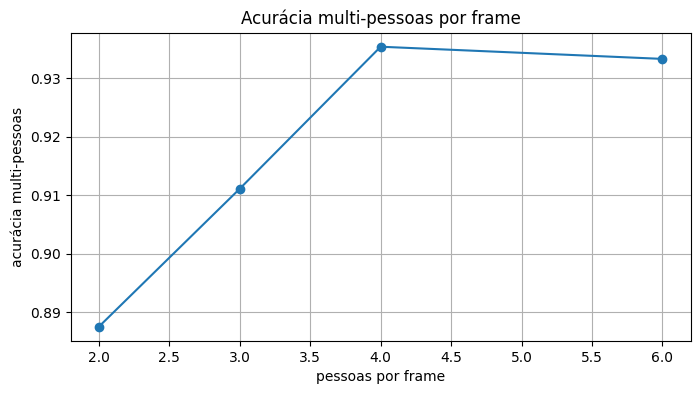

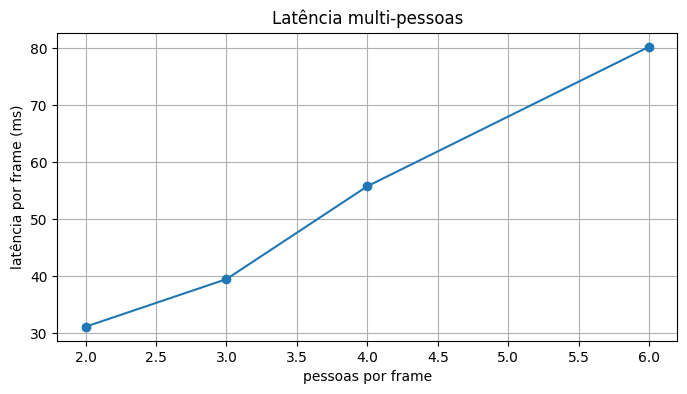

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(df_resultados_multi["pessoas_por_frame"], df_resultados_multi["multi_face_accuracy"], marker="o")
plt.xlabel("pessoas por frame")
plt.ylabel("acurácia multi-pessoas")
plt.title("Acurácia multi-pessoas por frame")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_resultados_multi["pessoas_por_frame"], df_resultados_multi["latency_frame_ms"], marker="o")
plt.xlabel("pessoas por frame")
plt.ylabel("latência por frame (ms)")
plt.title("Latência multi-pessoas")
plt.grid(True)
plt.show()


# 13. Tracking por IoU


In [29]:
class TrackIoU:
    def __init__(self, track_id, bbox, label_pred, frame_id):
        self.track_id = track_id
        self.bbox = bbox
        self.label_pred = label_pred
        self.last_frame = frame_id
        self.recognitions = 1

class TrackerSimplesIoU:
    def __init__(self, iou_threshold=0.25, max_age=3, recognition_cooldown_frames=5):
        self.iou_threshold = iou_threshold
        self.max_age = max_age
        self.recognition_cooldown_frames = recognition_cooldown_frames
        self.tracks = {}
        self.next_id = 1
        self.total_recognitions = 0

    def atualizar(self, detections, frame_id):
        atribuicoes = []
        usados = set()

        for det in detections:
            melhor_track_id = None
            melhor_iou = 0

            for track_id, track in self.tracks.items():
                if track_id in usados:
                    continue

                iou = calcular_iou(det["bbox"], track.bbox)

                if iou > melhor_iou:
                    melhor_iou = iou
                    melhor_track_id = track_id

            if melhor_track_id is not None and melhor_iou >= self.iou_threshold:
                track = self.tracks[melhor_track_id]
                precisa_reconhecer = frame_id - track.last_frame >= self.recognition_cooldown_frames

                track.bbox = det["bbox"]
                track.last_frame = frame_id

                if precisa_reconhecer:
                    track.label_pred = det["label_final"]
                    track.recognitions += 1
                    self.total_recognitions += 1

                usados.add(melhor_track_id)

                atribuicoes.append({
                    "track_id": melhor_track_id,
                    "bbox": det["bbox"],
                    "pred_label": track.label_pred,
                    "recognized_now": precisa_reconhecer,
                })
            else:
                track_id = self.next_id
                self.next_id += 1

                self.tracks[track_id] = TrackIoU(
                    track_id=track_id,
                    bbox=det["bbox"],
                    label_pred=det["label_final"],
                    frame_id=frame_id,
                )

                self.total_recognitions += 1

                atribuicoes.append({
                    "track_id": track_id,
                    "bbox": det["bbox"],
                    "pred_label": det["label_final"],
                    "recognized_now": True,
                })

        remover = [
            track_id
            for track_id, track in self.tracks.items()
            if frame_id - track.last_frame > self.max_age
        ]

        for track_id in remover:
            del self.tracks[track_id]

        return atribuicoes

def mover_bbox(bbox, dx, dy):
    x1, y1, x2, y2 = bbox
    return [x1 + dx, y1 + dy, x2 + dx, y2 + dy]

def criar_sequencia_sintetica(amostras, total_frames=12):
    frame_base, anotacoes_base = criar_frame_sintetico(amostras)
    sequencia = []

    for frame_idx in range(total_frames):
        frame = Image.new("RGB", frame_base.size, color=(235, 235, 235))
        anotacoes = []

        for item, anotacao in zip(amostras, anotacoes_base):
            imagem = carregar_imagem_por_indice(item["indice"])
            imagem = ImageOps.fit(
                imagem,
                (
                    anotacao["bbox_gt"][2] - anotacao["bbox_gt"][0],
                    anotacao["bbox_gt"][3] - anotacao["bbox_gt"][1],
                ),
            )

            dx = frame_idx * random.randint(-2, 2)
            dy = frame_idx * random.randint(-1, 2)

            bbox = mover_bbox(anotacao["bbox_gt"], dx, dy)

            frame.paste(imagem, (bbox[0], bbox[1]))

            anotacoes.append({
                "label_str": item["label_str"],
                "tipo": item.get("tipo", "known"),
                "bbox_gt": bbox,
            })

        sequencia.append((frame, anotacoes))

    return sequencia

def avaliar_tracking():
    registros = []

    df_known_test = df_split[df_split["split"] == "test"].copy()
    labels_disponiveis = df_known_test["label_str"].unique().tolist()

    for seq_id in tqdm(range(TRACKING_TOTAL_SEQUENCIAS), desc="tracking"):
        labels_seq = random.sample(labels_disponiveis, TRACKING_PESSOAS_POR_SEQUENCIA)

        amostras = []

        for label in labels_seq:
            candidato = df_known_test[df_known_test["label_str"] == label].sample(1, random_state=random.randint(1, 999999)).iloc[0]
            amostras.append({
                "indice": int(candidato["indice"]),
                "label_str": candidato["label_str"],
                "tipo": "known",
            })

        sequencia = criar_sequencia_sintetica(amostras, total_frames=TRACKING_FRAMES_POR_SEQUENCIA)

        tracker = TrackerSimplesIoU()
        historico_gt_track = {}
        id_switches = 0
        total_detections = 0

        inicio_seq = time.perf_counter()

        for frame_id, (frame, anotacoes) in enumerate(sequencia):
            detections, _lat = reconhecer_frame_completo(frame, top_k=1)
            atribuicoes = tracker.atualizar(detections, frame_id)

            total_detections += len(detections)

            for gt in anotacoes:
                melhor_iou = 0
                melhor_track = None

                for atr in atribuicoes:
                    iou = calcular_iou(gt["bbox_gt"], atr["bbox"])

                    if iou > melhor_iou:
                        melhor_iou = iou
                        melhor_track = atr["track_id"]

                if melhor_track is not None and melhor_iou >= 0.10:
                    label = gt["label_str"]

                    if label in historico_gt_track and historico_gt_track[label] != melhor_track:
                        id_switches += 1

                    historico_gt_track[label] = melhor_track

        latencia_seq_ms = (time.perf_counter() - inicio_seq) * 1000

        reconhecimentos_sem_tracking = TRACKING_FRAMES_POR_SEQUENCIA * TRACKING_PESSOAS_POR_SEQUENCIA
        reconhecimentos_com_tracking = tracker.total_recognitions

        registros.append({
            "seq_id": seq_id,
            "frames": TRACKING_FRAMES_POR_SEQUENCIA,
            "pessoas": TRACKING_PESSOAS_POR_SEQUENCIA,
            "detections": total_detections,
            "id_switches": id_switches,
            "recognitions_without_tracking": reconhecimentos_sem_tracking,
            "recognitions_with_tracking": reconhecimentos_com_tracking,
            "recognition_reduction_rate": 1 - (reconhecimentos_com_tracking / max(reconhecimentos_sem_tracking, 1)),
            "latency_sequence_ms": latencia_seq_ms,
        })

    return pd.DataFrame(registros)

df_tracking = avaliar_tracking()
display(df_tracking.describe())

resumo_tracking = {
    "mean_id_switches": df_tracking["id_switches"].mean(),
    "mean_recognition_reduction_rate": df_tracking["recognition_reduction_rate"].mean(),
    "mean_latency_sequence_ms": df_tracking["latency_sequence_ms"].mean(),
}

pd.DataFrame([resumo_tracking])


tracking:   0%|          | 0/30 [00:00<?, ?it/s]

,seq_id,frames,pessoas,detections,id_switches,recognitions_without_tracking,recognitions_with_tracking,recognition_reduction_rate,latency_sequence_ms
count,30.000000,30.0,30.0,30.000000,30.000000,30.0,30.000000,30.000000,30.000000
mean,14.500000,12.0,4.0,46.533333,0.066667,48.0,4.033333,0.915972,668.627591
std,8.803408,0.0,0.0,2.968029,0.253708,0.0,0.319842,0.006663,70.876879
min,0.000000,12.0,4.0,36.000000,0.000000,48.0,3.000000,0.895833,524.866845
25%,7.250000,12.0,4.0,47.250000,0.000000,48.0,4.000000,0.916667,648.224894
50%,14.500000,12.0,4.0,48.000000,0.000000,48.0,4.000000,0.916667,657.449206
75%,21.750000,12.0,4.0,48.000000,0.000000,48.0,4.000000,0.916667,676.200495
max,29.000000,12.0,4.0,48.000000,1.000000,48.0,5.000000,0.937500,815.678908


,mean_id_switches,mean_recognition_reduction_rate,mean_latency_sequence_ms
0,0.066667,0.915972,668.627591


# 14. Latência e throughput


In [30]:
def medir_latencia_funcao(funcao, entradas, repeticoes=50):
    tempos = []

    for entrada in entradas[:repeticoes]:
        inicio = time.perf_counter()
        _ = funcao(entrada)
        tempos.append((time.perf_counter() - inicio) * 1000)

    return {
        "media_ms": float(np.mean(tempos)),
        "p50_ms": float(np.percentile(tempos, 50)),
        "p95_ms": float(np.percentile(tempos, 95)),
        "desvio_ms": float(np.std(tempos)),
    }

amostras_latencia = [
    carregar_imagem_por_indice(indice)
    for indice in df_test["indice"].sample(min(80, len(df_test)), random_state=SEED).tolist()
]

latencia_buffalo = medir_latencia_funcao(
    lambda img: extrair_embedding_buffalo_s(img),
    amostras_latencia,
    repeticoes=min(60, len(amostras_latencia)),
)

def inferir_resnet_pil(img):
    modelo_resnet.eval()
    tensor = transform_eval(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        _ = modelo_resnet(tensor)
    return None

latencia_resnet = medir_latencia_funcao(
    inferir_resnet_pil,
    amostras_latencia,
    repeticoes=min(60, len(amostras_latencia)),
)

amostras_features = X_pair_test[:1000]

inicio = time.perf_counter()
_ = melhor_verificador.predict_proba(amostras_features)
latencia_verificador_ms = ((time.perf_counter() - inicio) * 1000) / len(amostras_features)

inicio = time.perf_counter()
_ = buscar_topk(X_test_emb[:1000], top_k=3)
latencia_busca_ms = ((time.perf_counter() - inicio) * 1000) / min(1000, len(X_test_emb))

df_latencia = pd.DataFrame([
    {"componente": "buffalo_s_embedding", **latencia_buffalo},
    {"componente": "resnet50_inferencia", **latencia_resnet},
    {"componente": "verificador_auxiliar_por_par", "media_ms": latencia_verificador_ms, "p50_ms": latencia_verificador_ms, "p95_ms": latencia_verificador_ms, "desvio_ms": 0},
    {"componente": "busca_vetorial_por_face", "media_ms": latencia_busca_ms, "p50_ms": latencia_busca_ms, "p95_ms": latencia_busca_ms, "desvio_ms": 0},
])

df_latencia


,componente,media_ms,p50_ms,p95_ms,desvio_ms
0,buffalo_s_embedding,15.806070,15.686664,17.060589,0.815935
1,resnet50_inferencia,7.413636,6.959047,7.381880,3.163573
2,verificador_auxiliar_por_par,0.000663,0.000663,0.000663,0.000000
3,busca_vetorial_por_face,0.002990,0.002990,0.002990,0.000000


# 15. Comparação final


In [31]:
comparacao_final = pd.DataFrame([
    {
        "abordagem": "buffalo_s + busca vetorial",
        "tipo": "embedding + nearest neighbor",
        "metrica_principal": "top1_accuracy_closed_set",
        "valor": metricas_id_test["top1_accuracy"],
        "cadastro_incremental": True,
        "open_set": True,
        "multi_pessoas": True,
        "tracking_compativel": True,
        "adequado_producao": True,
    },
    {
        "abordagem": f"buffalo_s + {melhor_nome_verificador}",
        "tipo": "embedding + verificador auxiliar",
        "metrica_principal": "f1_match_non_match",
        "valor": float(df_resultados_verificacao.iloc[0]["f1_test_eer"]),
        "cadastro_incremental": True,
        "open_set": True,
        "multi_pessoas": True,
        "tracking_compativel": True,
        "adequado_producao": True,
    },
    {
        "abordagem": "ResNet50 fine-tuned",
        "tipo": "classificador fechado",
        "metrica_principal": "macro_f1",
        "valor": resumo_resnet_test["test_macro_f1"],
        "cadastro_incremental": False,
        "open_set": False,
        "multi_pessoas": False,
        "tracking_compativel": False,
        "adequado_producao": False,
    },
])

comparacao_final


,abordagem,tipo,metrica_principal,valor,cadastro_incremental,open_set,multi_pessoas,tracking_compativel,adequado_producao
0,buffalo_s + busca vetorial,embedding + nearest neighbor,top1_accuracy_closed_set,0.985867,True,True,True,True,True
1,buffalo_s + LogisticRegression,embedding + verificador auxiliar,f1_match_non_match,0.955384,True,True,True,True,True
2,ResNet50 fine-tuned,classificador fechado,macro_f1,0.624762,False,False,False,False,False


# 16. Exportação dos artefatos


In [32]:
artefato_verificador = {
    "classifier": melhor_verificador,
    "classifier_name": melhor_nome_verificador,
    "threshold_match": melhor_threshold,
    "threshold_open_set": threshold_open_set,
    "feature_names": FEATURE_NAMES,
    "embedding_model": INSIGHTFACE_MODEL,
    "embedding_dim": int(X_train_emb.shape[1]),
    "created_at": datetime.utcnow().isoformat(),
    "dataset": DATASET_NAME,
    "total_amostras_dataset": TOTAL_AMOSTRAS_DATASET,
    "total_imagens_experimento": int(len(df_split)),
    "num_known_classes": int(NUM_CLASSES),
    "num_unknown_classes": int(len(labels_unknown)),
}

caminho_pkl = PASTA_ARTEFATOS / "classificador_match_embeddings_buffalo_s.pkl"
joblib.dump(artefato_verificador, caminho_pkl)

metricas = {
    "identificacao_fechada": df_metricas_identificacao.to_dict(orient="records"),
    "open_set": metricas_open_set,
    "verificacao": df_resultados_verificacao.to_dict(orient="records"),
    "multi_face": df_resultados_multi.to_dict(orient="records"),
    "tracking": resumo_tracking,
    "latencia": df_latencia.to_dict(orient="records"),
    "comparacao_final": comparacao_final.to_dict(orient="records"),
    "resnet50": resumo_resnet_test,
}

caminho_metricas = PASTA_ARTEFATOS / "metricas_experimento.json"
with open(caminho_metricas, "w", encoding="utf-8") as arquivo:
    json.dump(metricas, arquivo, indent=2, ensure_ascii=False)

caminho_classes = PASTA_ARTEFATOS / "classes_conhecidas.json"
with open(caminho_classes, "w", encoding="utf-8") as arquivo:
    json.dump(label_encoder.classes_.tolist(), arquivo, indent=2, ensure_ascii=False)

arquivo_zip = BASE_DIR / "artefatos_reconhecimento.zip"

if arquivo_zip.exists():
    arquivo_zip.unlink()

shutil.make_archive(
    base_name=str(arquivo_zip).replace(".zip", ""),
    format="zip",
    root_dir=PASTA_ARTEFATOS,
)

print("PKL:", caminho_pkl)
print("Métricas:", caminho_metricas)
print("Classes:", caminho_classes)
print("ZIP:", arquivo_zip)


PKL: /content/artefatos_reconhecimento/classificador_match_embeddings_buffalo_s.pkl
Métricas: /content/artefatos_reconhecimento/metricas_experimento.json
Classes: /content/artefatos_reconhecimento/classes_conhecidas.json
ZIP: /content/artefatos_reconhecimento.zip


# Conclusão Técnica

Os resultados do notebook estão coerentes com o objetivo do projeto de reconhecimento facial. O experimento utilizou 70.000 imagens do dataset `chronopt-research/cropped-vggface2-224`, mantendo 194 identidades válidas. Dessas 165 identidades foram tratadas como pessoas conhecidas/cadastradas e 29 identidades foram separadas como pessoas desconhecidas, permitindo avaliar também o cenário open-set.

As imagens avaliadas possuem tamanho padronizado de 224x224, o que favorece a consistência do experimento. Após a extração de embeddings com `buffalo_s` foram obtidos 41.073 embeddings para treino, 8.737 para validação conhecida, 8.986 para teste conhecido, 5.424 para validação desconhecida e 5.435 para teste desconhecido.

## Pipeline principal

O melhor resultado geral foi obtido com a abordagem:

```text
buffalo_s + embeddings + busca vetorial
```

No cenário fechado com pessoas conhecidas, o modelo obteve:

```text
Top-1 Test: 0.985867
Top-3 Test: 0.991320
Macro F1 Test: 0.983990
```

Esses resultados são fortes e coerentes principalmente porque o `buffalo_s` é especializado em gerar embeddings faciais robustos. Diferente dos testes anteriores com que obteve 100%, agora os resultados parecem mais realistas pois o notebook usa uma amostra maior, mais identidades e avaliação open-set.

## Rejeição de desconhecidos

A avaliação open-set também ficou coerente com um sistema. O modelo obteve:

```text
AUC Open-set Validação: 0.986043
EER Open-set Validação: 0.034785
Unknown Rejection Rate: 0.960442
False Acceptance Rate: 0.039558
False Rejection Rate: 0.033719
Open-set Balanced Accuracy: 0.963361
```

Isso mostra que o sistema consegue rejeitar a maior parte das pessoas não cadastradas, mantendo uma taxa de falso aceite relativamente baixa.

## Classificador auxiliar

O melhor classificador auxiliar foi a `LogisticRegression` com:

```text
AUC Test: 0.988547
F1 Test: 0.955384
Precision Test: 0.959080
Recall Test: 0.951717
```

O resultado indica que o classificador auxiliar é útil para validar pares de embeddings em casos duvidosos. Porém, ele não deve ser o centro da arquitetura. O papel mais adequado dele é atuar como uma camada complementar quando a similaridade vetorial estiver em uma zona intermediária.

## ResNet50

A `ResNet50` com transfer learning e fine-tuning obteve:

```text
Accuracy Test: 0.637532
Macro F1 Test: 0.624762
Precision Macro Test: 0.653555
Recall Macro Test: 0.622801
```

O resultado é inferior ao pipeline com `buffalo_s`. Isso é coerente pois a ResNet50 foi usada como classificador fechado para 165 classes conhecidas. Esse tipo de abordagem não é ideal para o projeto porque novos alunos exigiriam retreinamento do modelo. Para um sistema de presença facial, a abordagem por embeddings é mais adequada pois permite cadastro incremental.

## Multi-pessoas no mesmo frame

O teste multi-pessoas mostrou que o pipeline consegue lidar com mais de uma pessoa simultaneamente:

```text
2 pessoas: acurácia 0.887500 | latência 31.16 ms
3 pessoas: acurácia 0.911111 | latência 39.51 ms
4 pessoas: acurácia 0.935417 | latência 55.80 ms
6 pessoas: acurácia 0.933333 | latência 80.25 ms
```

Os resultados são coerentes com a proposta do sistema. A latência aumenta conforme o número de pessoas cresce mas ainda permanece em uma faixa aceitável para tempo real especialmente usando GPU.

## Tracking

A simulação de tracking por IoU apresentou resultado positivo. Em média, o sistema reduziu fortemente a quantidade de reconhecimentos repetidos:

```text
Reconhecimentos sem tracking: 48 por sequência
Reconhecimentos com tracking: aproximadamente 4 por sequência
Média de ID switches: 0.0667
```

Isso confirma que tracking é uma etapa importante para produção. Em vez de reconhecer a mesma pessoa em todos os frames, o sistema reconhece uma vez e acompanha a posição da face, reduzindo custo computacional e melhorando a fluidez em tempo real.

## Latência

As medições de latência também são coerentes:

```text
buffalo_s embedding: 15.81 ms
ResNet50 inferência: 7.41 ms
verificador auxiliar: 0.000663 ms
busca vetorial: 0.002990 ms
```

A ResNet50 é mais rápida na inferência isolada mas entrega desempenho inferior e não se adapta bem ao cadastro incremental. O `buffalo_s` é mais custoso por face mas oferece embeddings muito mais adequados para busca vetorial, open-set e reconhecimento de múltiplas pessoas.

## Decisão

Com base nos resultados, a arquitetura mais adequada para o projeto é:

```text
buffalo_s
↓
embedding facial
↓
Firebase face_embeddings
↓
índice vetorial em memória
↓
busca por similaridade
↓
rejeição de desconhecidos
↓
classificador auxiliar em casos duvidosos
↓
tracking temporal
↓
registro de presença
```

A `ResNet50` deve permanecer apenas como comparação técnica, pois não é a melhor escolha para produção. O modelo principal recomendado é `buffalo_s + busca vetorial`, com classificador auxiliar e tracking para melhorar robustez e desempenho em tempo real.

Portanto, os resultados estão coerentes com o trabalho e indicam que a solução baseada em embeddings é mais adequada para um sistema real de reconhecimento facial de alunos.
